In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import seaborn as sns



import warnings
warnings.filterwarnings('ignore')

## Preparation and data wrangling- Actual Duration

In [3]:
ad = pd.read_csv('actual_duration.csv')

ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [4]:
# Import the addtion file for ICB Name and Region
Region_ICE_List= pd.read_csv('Region_ICE_List.csv')
Region_ICE_List.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   icb_ons_code     42 non-null     object
 1   ICB Name         42 non-null     object
 2   region_ons_code  42 non-null     object
 3   Region           42 non-null     object
dtypes: object(4)
memory usage: 1.4+ KB


In [5]:
# Merge ad with region and icb name.
ad_region= pd.merge(ad, 
              Region_ICE_List[['icb_ons_code','ICB Name','region_ons_code','Region']],\
              how='left', on='icb_ons_code')

ad_region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code_x          137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
 8   ICB Name                   137793 non-null  object
 9   region_ons_code_y          137793 non-null  object
 10  Region                     137793 non-null  object
dtypes: int64(1), object(10)
memory usage: 11.6+ MB


In [6]:
ad_region.head()


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code_x,appointment_date,actual_duration,count_of_appointments,ICB Name,region_ons_code_y,Region
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364,North East and North Cumbria ICB,E40000012,North East and Yorkshire
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619,North East and North Cumbria ICB,E40000012,North East and Yorkshire
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698,North East and North Cumbria ICB,E40000012,North East and Yorkshire
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277,North East and North Cumbria ICB,E40000012,North East and Yorkshire
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730,North East and North Cumbria ICB,E40000012,North East and Yorkshire


In [7]:
ad_region.tail()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code_x,appointment_date,actual_duration,count_of_appointments,ICB Name,region_ons_code_y,Region
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430,West Yorkshire ICB,E40000012,North East and Yorkshire
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751,West Yorkshire ICB,E40000012,North East and Yorkshire
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921,West Yorkshire ICB,E40000012,North East and Yorkshire
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439,West Yorkshire ICB,E40000012,North East and Yorkshire
137792,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,1-5 Minutes,1739,West Yorkshire ICB,E40000012,North East and Yorkshire


In [8]:
missing_values = ad_region.isnull().sum()

print("Missing values per column:")
print(missing_values)

if ad_region.isnull().values.any():
    print("\nThere are missing values in the ad_region.")
else:
    print("\nNo missing values in ad_region.")

Missing values per column:
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code_x            0
appointment_date             0
actual_duration              0
count_of_appointments        0
ICB Name                     0
region_ons_code_y            0
Region                       0
dtype: int64

No missing values in ad_region.


In [9]:
ad_region.duplicated().sum()

if ad_region.duplicated().values.any():
    print("\nThere are duplicated data in ad_region.")
else:
    print("\nNo duplicated data in ad_region.")


No duplicated data in ad_region.


In [10]:
ad_region.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


## Preparation and data wrangling- Appointments Regional

In [12]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv', usecols=lambda col: col not in ['Unnamed: 7', 'Unnamed: 8'])

# View the DataFrame.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [13]:
ar_region= pd.merge(ar, 
              Region_ICE_List[['icb_ons_code','ICB Name','region_ons_code','Region']],\
              how='left', on='icb_ons_code')

ar_region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 10 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
 7   ICB Name                           596821 non-null  object
 8   region_ons_code                    596821 non-null  object
 9   Region                             596821 non-null  object
dtypes: int64(1), object(9)
memory usage: 45.5+ MB


In [14]:
ar_region.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,ICB Name,region_ons_code,Region
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,Frimley ICB,E40000005,South East
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,Frimley ICB,E40000005,South East
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,Frimley ICB,E40000005,South East
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,Frimley ICB,E40000005,South East
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,Frimley ICB,E40000005,South East


In [15]:
ar_region.tail()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,ICB Name,region_ons_code,Region
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21,North East and North Cumbria ICB,E40000012,North East and Yorkshire
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8,North East and North Cumbria ICB,E40000012,North East and Yorkshire
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28,North East and North Cumbria ICB,E40000012,North East and Yorkshire
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17,North East and North Cumbria ICB,E40000012,North East and Yorkshire
596820,E54000050,2022-06,Unknown,Unknown,Unknown,Same Day,10,North East and North Cumbria ICB,E40000012,North East and Yorkshire


In [16]:
missing_values = ar_region.isnull().sum()

print("Missing values per column:")
print(missing_values)

if ad_region.isnull().values.any():
    print("\nThere are missing values in the ar_region.")
else:
    print("\nNo missing values in ar_region.")

Missing values per column:
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
ICB Name                             0
region_ons_code                      0
Region                               0
dtype: int64

No missing values in ar_region.


In [17]:
ar_region.duplicated().sum()

if ar_region.duplicated().values.any():
    print("\nThere are duplicated data in ar_region.")
else:
    print("\nNo duplicated data in ar_region.")


There are duplicated data in ar_region.


In [18]:
num_duplicates = ar_region.duplicated().sum()
print(f"\nNumber of duplicated rows in ar_region: {num_duplicates}")


Number of duplicated rows in ar_region: 21604


In [19]:
ar_region.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


## Preparation and data wrangling- National Categories

In [21]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')

nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [22]:
# Merge nc with region and icb name.
nc_region= pd.merge(nc, 
              Region_ICE_List[['icb_ons_code','ICB Name','region_ons_code','Region']],\
              how='left', on='icb_ons_code')

nc_region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
 8   ICB Name               817394 non-null  object        
 9   region_ons_code        817394 non-null  object        
 10  Region                 817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 68.6+ MB


In [23]:
nc_region.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,ICB Name,region_ons_code,Region
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08,North East and North Cumbria ICB,E40000012,North East and Yorkshire
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08,North East and North Cumbria ICB,E40000012,North East and Yorkshire
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08,North East and North Cumbria ICB,E40000012,North East and Yorkshire
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08,North East and North Cumbria ICB,E40000012,North East and Yorkshire
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08,North East and North Cumbria ICB,E40000012,North East and Yorkshire


In [24]:
nc_region.tail()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,ICB Name,region_ons_code,Region
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06,West Yorkshire ICB,E40000012,North East and Yorkshire
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06,West Yorkshire ICB,E40000012,North East and Yorkshire
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06,West Yorkshire ICB,E40000012,North East and Yorkshire
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06,West Yorkshire ICB,E40000012,North East and Yorkshire
817393,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Acute,19,2022-06,West Yorkshire ICB,E40000012,North East and Yorkshire


In [25]:
# Determine whether there are missing values.
missing_values = nc_region.isnull().sum()

print("Missing values per column:")
print(missing_values)

if nc_region.isnull().values.any():
    print("\nThere are missing values in the DataFrame.")
else:
    print("\nNo missing values in the DataFrame.")

Missing values per column:
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
ICB Name                 0
region_ons_code          0
Region                   0
dtype: int64

No missing values in the DataFrame.


In [26]:
nc_region.duplicated().sum()

if nc_region.duplicated().values.any():
    print("\nThere are duplicated data in nc_region.")
else:
    print("\nNo duplicated data in nc_region.")


No duplicated data in nc_region.


In [27]:
nc_region.describe()

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


In [28]:
#create ad_region_weekday dataframe to show which weekday of each record

# Convert 'appointment_date' to datetime format 
ad_region['appointment_date'] = pd.to_datetime(ad_region['appointment_date'])

# Create a new dataframe with an added weekday column
ad_region_weekday = ad_region.copy()  # Copy the original dataframe
ad_region_weekday['weekday'] = ad_region_weekday['appointment_date'].dt.day_name()

ad_region_weekday.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code_x,appointment_date,actual_duration,count_of_appointments,ICB Name,region_ons_code_y,Region,weekday
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,North East and North Cumbria ICB,E40000012,North East and Yorkshire,Wednesday
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,North East and North Cumbria ICB,E40000012,North East and Yorkshire,Wednesday
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,North East and North Cumbria ICB,E40000012,North East and Yorkshire,Wednesday
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,North East and North Cumbria ICB,E40000012,North East and Yorkshire,Wednesday
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,North East and North Cumbria ICB,E40000012,North East and Yorkshire,Wednesday


## Explore the data set

How many locations are there in the data set?

In [31]:
# Determine the number of locations.

#icb_ons_location
#from ar
ar_icb_ons_code = ar["icb_ons_code"].nunique()
print (ar_icb_ons_code)

#from ad
ad_icb_ons_code = ad["icb_ons_code"].nunique()
print (ad_icb_ons_code)

#from nc
icb_ons_code = nc["icb_ons_code"].nunique()
print (icb_ons_code)

#sub_icb_location

#from ad
ad_sub_icb_location_code = ad["sub_icb_location_code"].nunique()
print (ad_sub_icb_location_code)

ad_sub_icb_location_ons_code = ad["sub_icb_location_ons_code"].nunique()
print (ad_sub_icb_location_ons_code)
#from nc
sub_icb_location_name = nc["sub_icb_location_name"].nunique()
print (sub_icb_location_name)

42
42
42
106
106
106


**Question 2:** What are the three locations with the highest number of appointments?

In [33]:
appointments_by_location = ar_region.groupby('Region')['count_of_appointments'].sum()
sorted_location = appointments_by_location.sort_values(ascending=False)
top3_location = sorted_location.head(3)
print (top3_location)

Region
Midlands                    143625196
North East and Yorkshire    121448860
South East                  112144789
Name: count_of_appointments, dtype: int64


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [35]:
service_settings = nc['service_setting'].nunique()
unique_settings = nc['service_setting'].unique()

print(f'There are {service_settings} service settings:')
for setting in unique_settings:
    print(f'- {setting}')



There are 5 service settings:
- Primary Care Network
- Other
- General Practice
- Unmapped
- Extended Access Provision


In [36]:
context_types = nc['context_type'].nunique()
unique_context_types = nc['context_type'].unique()
print(f'There are {context_types} context types.')
for context_types in unique_context_types:
    print(f'- {context_types}')

There are 3 context types.
- Care Related Encounter
- Unmapped
- Inconsistent Mapping


In [37]:
context_types = nc['context_type'].nunique()
unique_context_types = nc['context_type'].unique()  # Correct column name

print(f'There are {context_types} context types:')
for context_type in unique_context_types:  # Use a different variable name
    print(f'- {context_type}')


There are 3 context types:
- Care Related Encounter
- Unmapped
- Inconsistent Mapping


In [38]:
appointment_status_count = ar['appointment_status'].nunique()
unique_appointment_statuses = ar['appointment_status'].unique()

# Print the count and list all unique statuses.
print(f'There are {appointment_status_count} appointment statuses:')
for status in unique_appointment_statuses:
    print(f'- {status}')


There are 3 appointment statuses:
- Attended
- DNA
- Unknown


In [39]:
national_category_count = nc['national_category'].nunique()
unique_national_categories = nc['national_category'].unique()

# Print the count and list all unique categories.
print(f'There are {national_category_count} national categories:')
for category in unique_national_categories:
    print(f'- {category}')



There are 18 national categories:
- Patient contact during Care Home Round
- Planned Clinics
- Home Visit
- General Consultation Acute
- Structured Medication Review
- Care Home Visit
- Unmapped
- Clinical Triage
- Planned Clinical Procedure
- Inconsistent Mapping
- Care Home Needs Assessment & Personalised Care and Support Planning
- General Consultation Routine
- Service provided by organisation external to the practice
- Unplanned Clinical Activity
- Social Prescribing Service
- Non-contractual chargeable work
- Group Consultation and Group Education
- Walk-in


**Question 1:** Between what dates were appointments scheduled? 

In [41]:
# Determine the minimum and maximum dates in the ad DataFrame.
# ad
max_date = ad_region['appointment_date'].max()
min_date = ad_region['appointment_date'].min()

print(f"Appointment schedule is from {min_date} to {max_date} in Actual Duration")

#nc
max_date = nc_region['appointment_date'].max()
min_date = nc_region['appointment_date'].min()

print(f"Appointment schedule is from {min_date} to {max_date} in National Categories")

#ar
max_date = ar_region['appointment_month'].max()
min_date = ar_region['appointment_month'].min()

print(f"Appointment schedule is from {min_date} to {max_date} in Appointments Regional")

Appointment schedule is from 2021-12-01 00:00:00 to 2022-06-30 00:00:00 in Actual Duration
Appointment schedule is from 2021-08-01 00:00:00 to 2022-06-30 00:00:00 in National Categories
Appointment schedule is from 2020-01 to 2022-06 in Appointments Regional


Question 3: Which month had the highest number of appointments?


In [43]:

monthly_appointments = ar_region.groupby('appointment_month')['count_of_appointments'].sum().reset_index()


max_month = monthly_appointments.loc[monthly_appointments['count_of_appointments'].idxmax()]


print("Month with the highest number of appointments:")
print(max_month)

Month with the highest number of appointments:
appointment_month         2021-11
count_of_appointments    30405070
Name: 22, dtype: object


## Visualization

### Objective 1
Create visualisations indicating the number of appointments per month for service settings, region, and national categories.

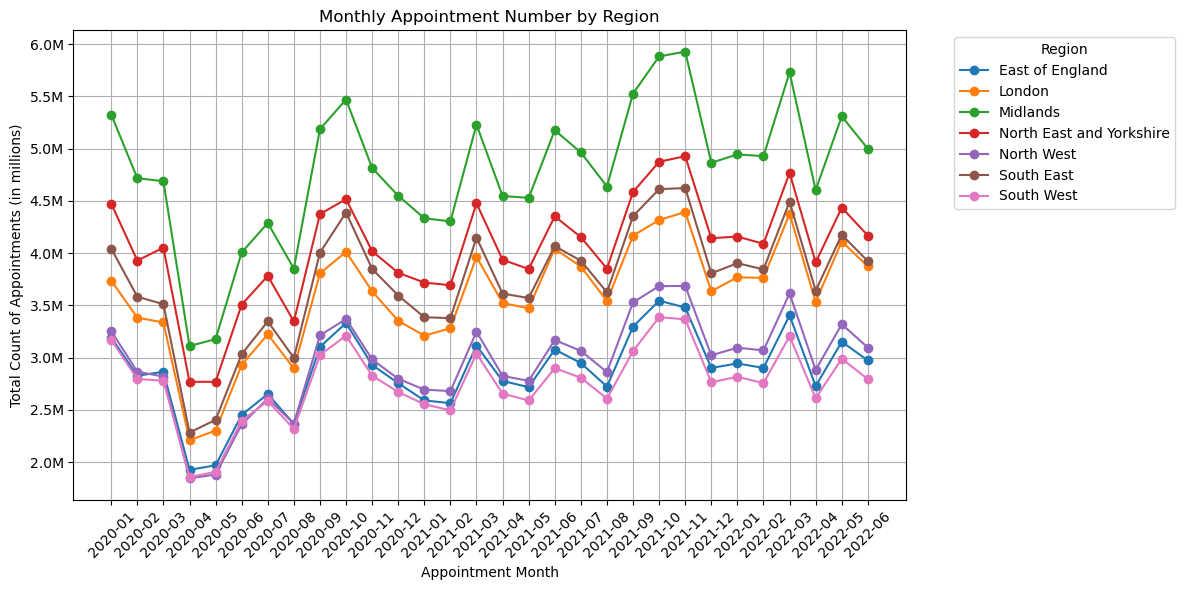

In [46]:


monthly_region_data = ar_region.groupby(['appointment_month', 'Region'])['count_of_appointments'].sum().unstack()


plt.figure(figsize=(12, 6))

for region in monthly_region_data.columns:
    plt.plot(monthly_region_data.index, monthly_region_data[region], marker='o', linestyle='-', label=region)


plt.xlabel('Appointment Month')
plt.ylabel('Total Count of Appointments (in millions)')
plt.title('Monthly Appointment Number by Region')
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.xticks(rotation=45)

plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()  
plt.savefig('Monthly Appointment Number by Region.png')
plt.show()

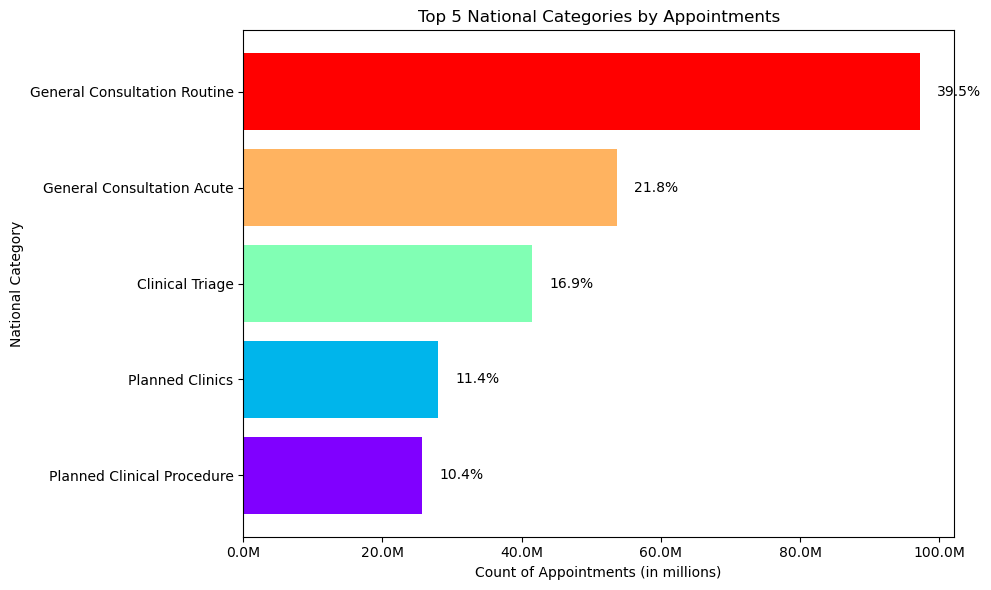

In [146]:
filtered_data = nc_region[~nc_region['national_category'].isin(['Unmapped', 'Inconsistent Mapping'])]

national_category_data = filtered_data.groupby('national_category')['count_of_appointments'].sum().reset_index()

top_5_categories = national_category_data.nlargest(5, 'count_of_appointments')

total_appointments = top_5_categories['count_of_appointments'].sum()
top_5_categories['percentage'] = (top_5_categories['count_of_appointments'] / total_appointments) * 100

top_5_categories = top_5_categories.sort_values(by='count_of_appointments', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.rainbow(np.linspace(0, 1, len(top_5_categories)))
bars = ax.barh(top_5_categories['national_category'], top_5_categories['count_of_appointments'], color=colors)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.xlabel('Count of Appointments (in millions)')
plt.ylabel('National Category')
plt.title('Top 5 National Categories by Appointments')


for bar, percentage in zip(bars, top_5_categories['percentage']):
    ax.text(bar.get_width() + total_appointments * 0.01,  
            bar.get_y() + bar.get_height()/2,  
            f'{percentage:.1f}%',  
            va='center')

plt.tight_layout()  
plt.savefig('Top 5 National Categories by Appointments.png')
plt.show()

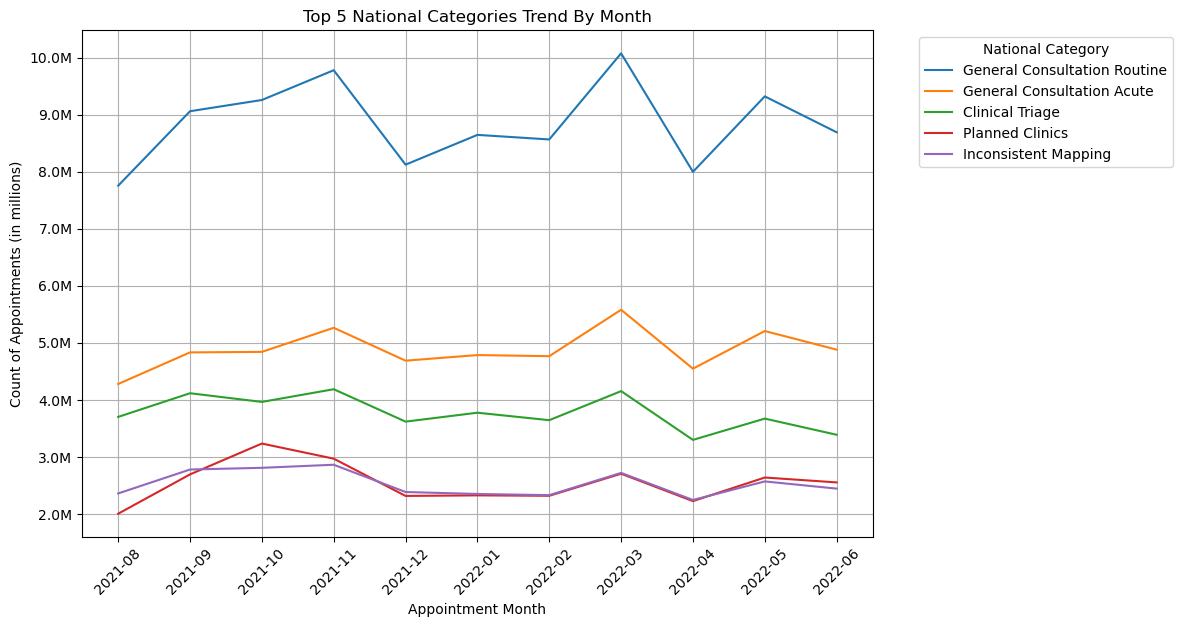

In [48]:

grouped_data = nc_region.groupby(['national_category', 'appointment_month'])['count_of_appointments'].sum().reset_index()

top_5_categories = grouped_data.groupby('national_category')['count_of_appointments'].sum().nlargest(5).index

filtered_data = grouped_data[grouped_data['national_category'].isin(top_5_categories)]

plt.figure(figsize=(12, 6))
for category in top_5_categories:
    category_data = filtered_data[filtered_data['national_category'] == category]
    plt.plot(category_data['appointment_month'], category_data['count_of_appointments'], label=category)


plt.xlabel('Appointment Month')
plt.ylabel('Count of Appointments (in millions)')
plt.title('Top 5 National Categories Trend By Month')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.legend(title='National Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('Top 5 National Categories Trend By Month.png')
plt.show()


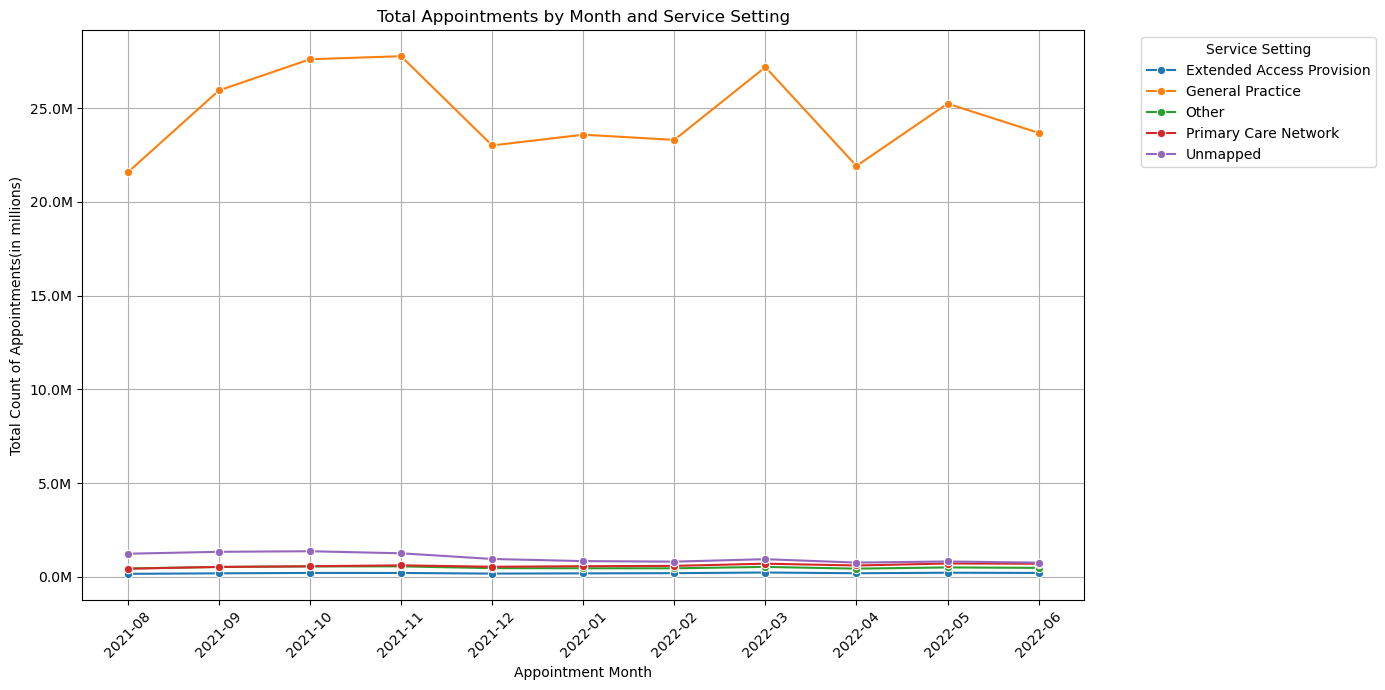

In [49]:

grouped_data = nc_region.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=grouped_data, x='appointment_month', y='count_of_appointments', hue='service_setting', marker='o')

plt.xlabel('Appointment Month')
plt.ylabel('Total Count of Appointments(in millions)')
plt.title('Total Appointments by Month and Service Setting')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.savefig('Total Appointments by Month and Service Setting')
plt.show()

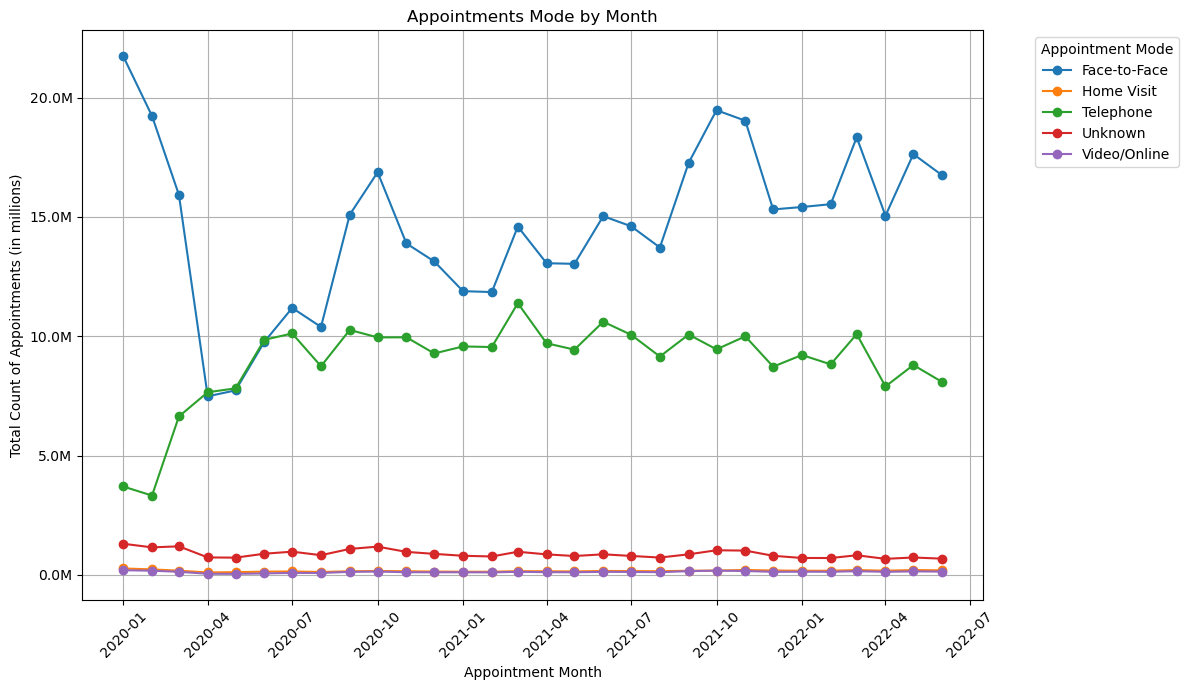

In [50]:
ar_region['appointment_month'] = pd.to_datetime(ar_region['appointment_month'], errors='coerce')


ar_region = ar_region.dropna(subset=['appointment_month'])
grouped_data = ar_region.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

for mode in grouped_data['appointment_mode'].unique():
    mode_data = grouped_data[grouped_data['appointment_mode'] == mode]
    ax.plot(mode_data['appointment_month'], mode_data['count_of_appointments'], 
            marker='o', linestyle='-', label=mode)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))


plt.xlabel('Appointment Month')
plt.ylabel('Total Count of Appointments (in millions)')
plt.title('Appointments Mode by Month')
plt.xticks(rotation=45)
plt.legend(title='Appointment Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('Appointments Mode Over Time.png')
plt.show()

### Objective 2
Create visualisations showing the Do Not Attend (DNA) rate and correlating parameters

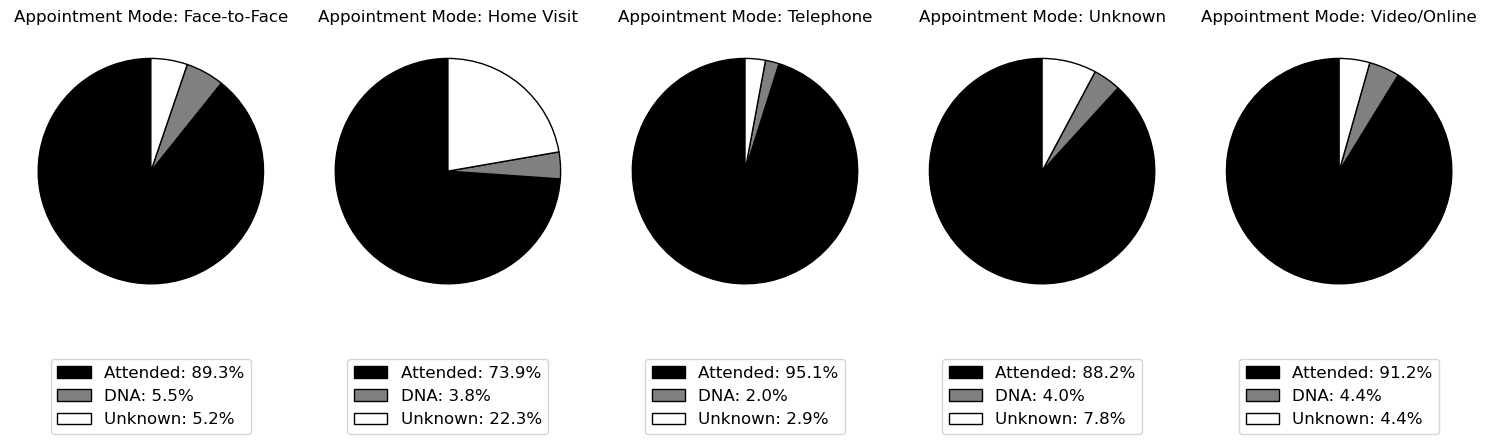

In [111]:
filtered_data = ar_region[ar_region['appointment_status'].isin(['DNA', 'Attended', 'Unknown'])]

grouped_data = filtered_data.groupby(['appointment_mode', 'appointment_status'])['count_of_appointments'].sum().unstack()

fig, axes = plt.subplots(nrows=1, ncols=len(grouped_data), figsize=(15, 6))

if len(grouped_data) == 1:
    axes = [axes]

for ax, (mode, counts) in zip(axes, grouped_data.iterrows()):
    percentages = (counts / counts.sum()) * 100
    
    ax.pie(
        counts, 
        labels=None,  # No labels on the pie chart itself
        colors=['black','grey', 'white'], 
        startangle=90, 
        wedgeprops={'edgecolor': 'black'}
    )
    ax.set_title(f"Appointment Mode: {mode}")
    
    legend_labels = [f"{status}: {percent:.1f}%" for status, percent in zip(counts.index, percentages)]

    ax.legend(
        legend_labels,
        loc='center', 
        bbox_to_anchor=(0.5, -0.3), 
        fontsize=12
    )

plt.tight_layout()
plt.savefig('DNA Percentage by Appointment Mode.png')
plt.show()

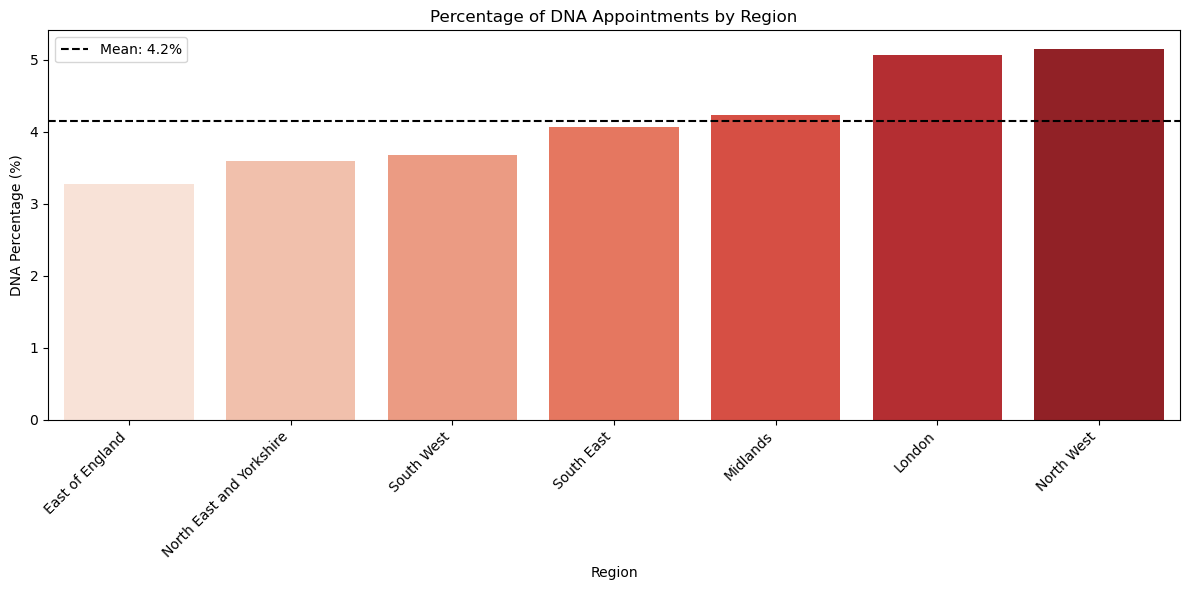

In [53]:

total_appointments = ar_region.groupby('Region')['count_of_appointments'].sum()

dna_appointments = ar_region[ar_region['appointment_status'] == 'DNA'].groupby('Region')['count_of_appointments'].sum()

dna_percentage = (dna_appointments / total_appointments) * 100
dna_percentage = dna_percentage.reset_index().sort_values(by='count_of_appointments', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=dna_percentage, x='Region', y='count_of_appointments', palette='Reds')

plt.xlabel('Region')
plt.ylabel('DNA Percentage (%)')
plt.title('Percentage of DNA Appointments by Region')

plt.xticks(rotation=45, ha='right')

mean_value = dna_percentage['count_of_appointments'].mean()
plt.axhline(mean_value, color='black', linestyle='dashed', label=f'Mean: {mean_value:.1f}%')

plt.legend()

plt.tight_layout()
plt.savefig('Percentage of DNA Appointments by Region.png')
plt.show()

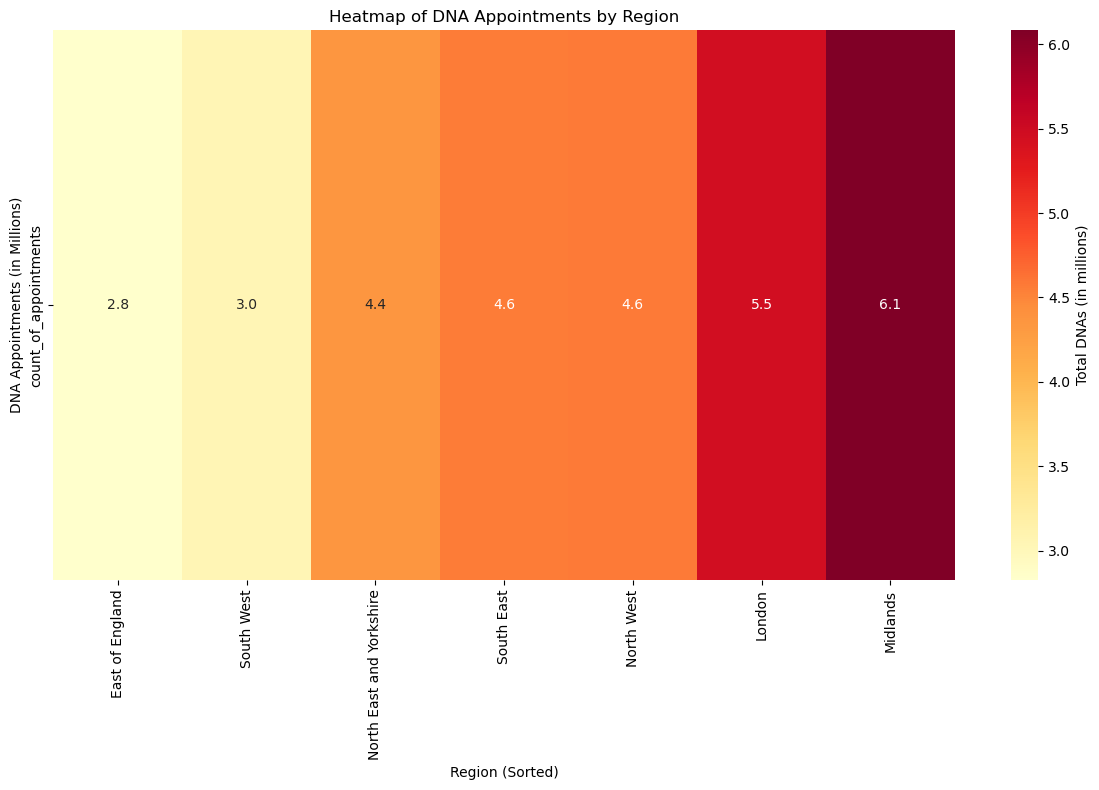

In [148]:

dna_data = ar_region[ar_region['appointment_status'] == 'DNA']


dna_grouped = dna_data.groupby('Region')['count_of_appointments'].sum().reset_index()

dna_grouped['count_of_appointments'] = dna_grouped['count_of_appointments'] / 1e6  # Convert to millions
dna_grouped = dna_grouped.sort_values(by='count_of_appointments', ascending=True)


heatmap_data = dna_grouped.set_index('Region').transpose()


plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Total DNAs (in millions)'})


plt.title('Heatmap of DNA Appointments by Region')
plt.xlabel('Region (Sorted)')
plt.ylabel('DNA Appointments (in Millions)')

plt.tight_layout()
plt.savefig('Heatmap of DNA Appointments by Region.png')
plt.show()

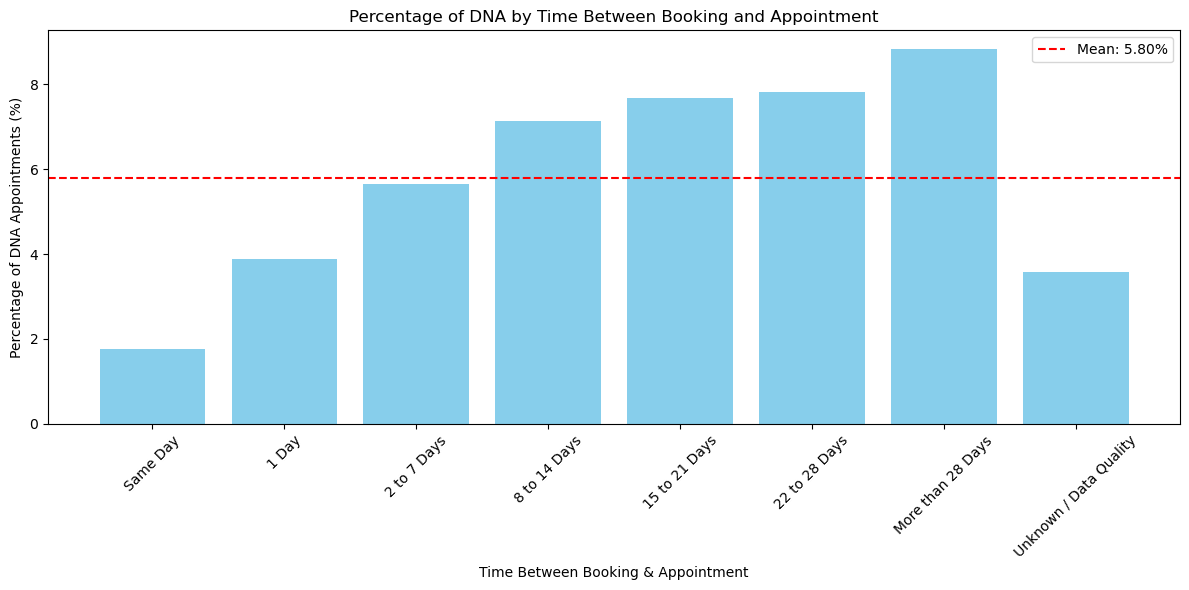

In [55]:
# Filter only 'DNA' from appointment_status
dna_data = ar[ar['appointment_status'] == 'DNA']


# Group by 'time_between_book_and_appointment' and sum 'count_of_appointments'
dna_grouped = dna_data.groupby('time_between_book_and_appointment')['count_of_appointments'].sum()

# Calculate the total count of appointments (for percentage calculation)
total_appointments_by_time = ar.groupby('time_between_book_and_appointment')['count_of_appointments'].sum()

# Calculate percentage of DNA for each 'time_between_book_and_appointment'
dna_percentage = (dna_grouped / total_appointments_by_time) * 100

# Define the correct order for 'time_between_book_and_appointment'
time_order = ['Same Day', '1 Day', '2 to 7 Days', '8 to 14 Days', '15 to 21 Days', 
              '22 to 28 Days', 'More than 28 Days', 'Unknown / Data Quality']

# Convert 'time_between_book_and_appointment' to a categorical type with the defined order
dna_percentage = dna_percentage.reindex(time_order)

# Create a bar chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(dna_percentage.index, dna_percentage, color='skyblue')

# Add a mean line
mean_dna_percentage = dna_percentage.mean()
ax.axhline(mean_dna_percentage, color='red', linestyle='--', label=f'Mean: {mean_dna_percentage:.2f}%')

# Add labels and title
ax.set_xlabel('Time Between Booking & Appointment')
ax.set_ylabel('Percentage of DNA Appointments (%)')
ax.set_title('Percentage of DNA by Time Between Booking and Appointment')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add the mean line legend
ax.legend()

# Show the chart
plt.tight_layout()
plt.savefig('Percentage of DNA by Time Between Booking and Appointment.png')
plt.show()


### Objective 3
Create visualisations related to Regions and correlating parameters

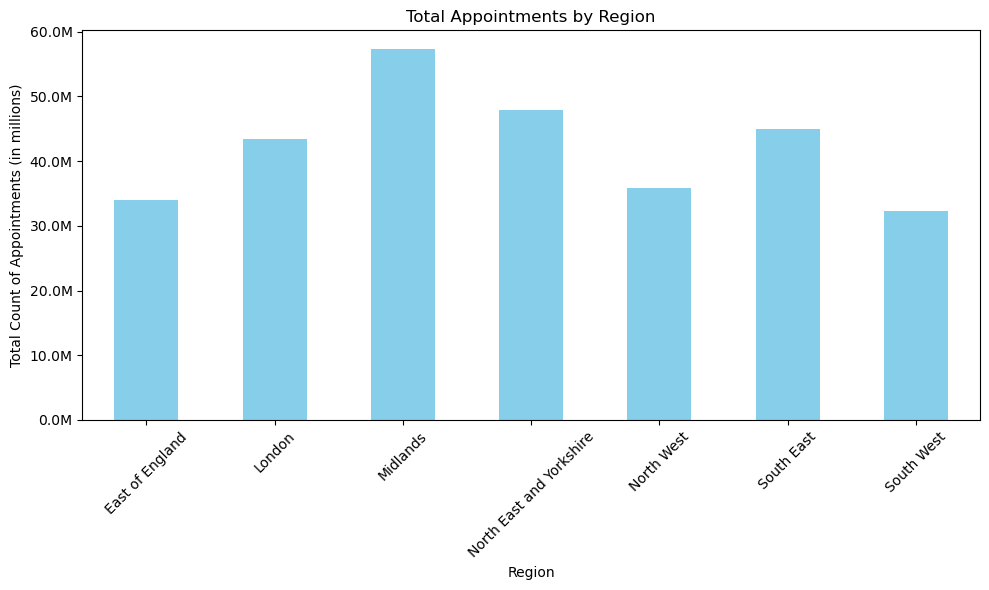

In [57]:
grouped_data = nc_region.groupby('Region')['count_of_appointments'].sum()


plt.figure(figsize=(10, 6))
grouped_data.plot(kind='bar', color='skyblue')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M'))


plt.xlabel('Region')
plt.ylabel('Total Count of Appointments (in millions)')
plt.title('Total Appointments by Region')
plt.xticks(rotation=45)

plt.tight_layout() 
plt.savefig('Total Appointments by Region.png')
plt.show()

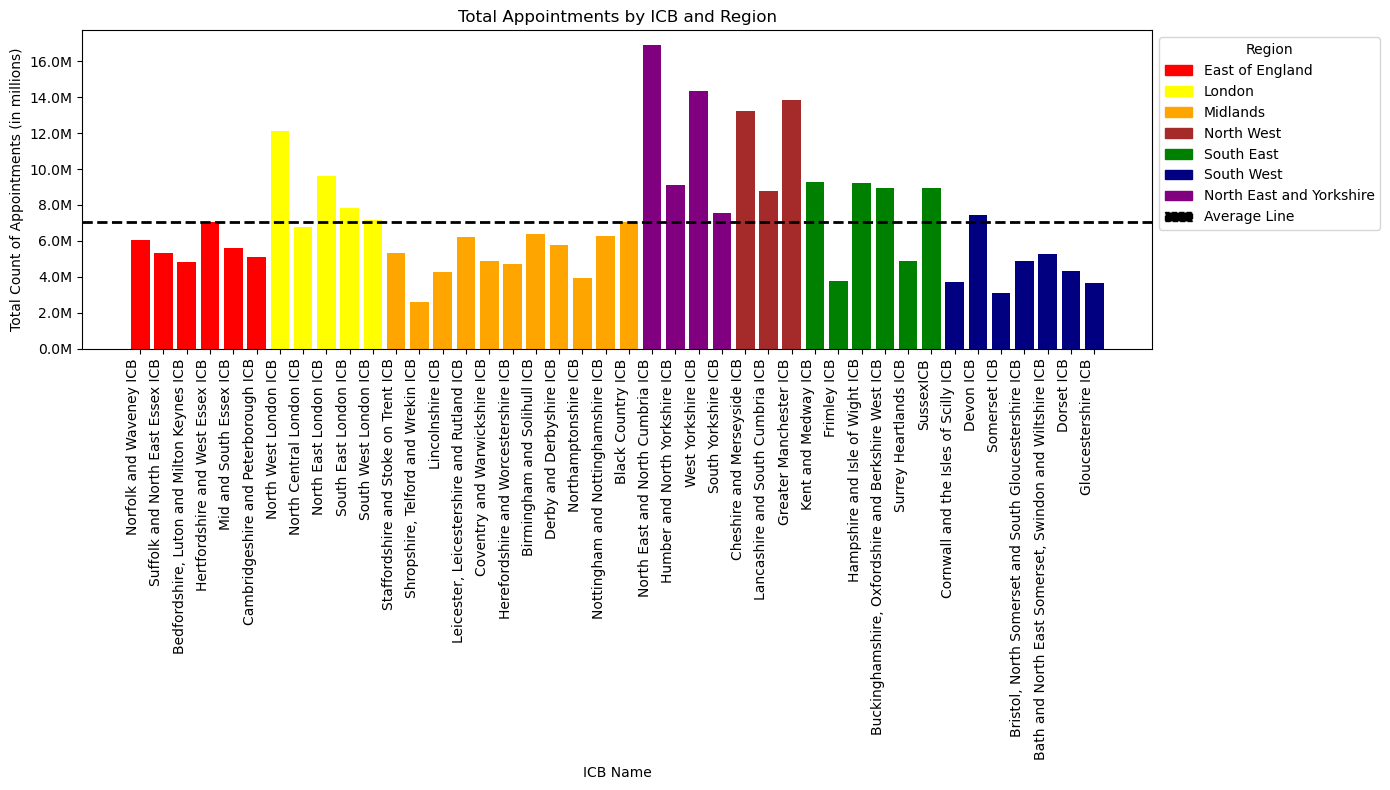

In [150]:

icb_order = [
    "Norfolk and Waveney ICB", "Suffolk and North East Essex ICB", "Bedfordshire, Luton and Milton Keynes ICB",
    "Hertfordshire and West Essex ICB", "Mid and South Essex ICB", "Cambridgeshire and Peterborough ICB",
    
    "North West London ICB", "North Central London ICB", "North East London ICB",
    "South East London ICB", "South West London ICB",
    
    "Staffordshire and Stoke on Trent ICB", "Shropshire, Telford and Wrekin ICB", "Lincolnshire ICB",
    "Leicester, Leicestershire and Rutland ICB", "Coventry and Warwickshire ICB",
    "Herefordshire and Worcestershire ICB", "Birmingham and Solihull ICB", "Derby and Derbyshire ICB",
    "Northamptonshire ICB", "Nottingham and Nottinghamshire ICB", "Black Country ICB",
    
    "North East and North Cumbria ICB", "Humber and North Yorkshire ICB",
    "West Yorkshire ICB", "South Yorkshire ICB",
    
    "Cheshire and Merseyside ICB", "Lancashire and South Cumbria ICB", "Greater Manchester ICB",
    
    "Kent and Medway ICB", "Frimley ICB", "Hampshire and Isle of Wight ICB",
    "Buckinghamshire, Oxfordshire and Berkshire West ICB", "Surrey Heartlands ICB", "SussexICB",
    
    "Cornwall and the Isles of Scilly ICB", "Devon ICB", "Somerset ICB",
    "Bristol, North Somerset and South Gloucestershire ICB",
    "Bath and North East Somerset, Swindon and Wiltshire ICB", "Dorset ICB", "Gloucestershire ICB"
]


color_map = {
    "Norfolk and Waveney ICB": "red", "Suffolk and North East Essex ICB": "red", 
    "Bedfordshire, Luton and Milton Keynes ICB": "red", "Hertfordshire and West Essex ICB": "red",
    "Mid and South Essex ICB": "red", "Cambridgeshire and Peterborough ICB": "red",
    
    "North West London ICB": "yellow", "North Central London ICB": "yellow", 
    "North East London ICB": "yellow", "South East London ICB": "yellow",
    "South West London ICB": "yellow",
    
    "Staffordshire and Stoke on Trent ICB": "orange", "Shropshire, Telford and Wrekin ICB": "orange",
    "Lincolnshire ICB": "orange", "Leicester, Leicestershire and Rutland ICB": "orange",
    "Coventry and Warwickshire ICB": "orange", "Herefordshire and Worcestershire ICB": "orange",
    "Birmingham and Solihull ICB": "orange", "Derby and Derbyshire ICB": "orange",
    "Northamptonshire ICB": "orange", "Nottingham and Nottinghamshire ICB": "orange",
    "Black Country ICB": "orange",
    
    "North East and North Cumbria ICB": "purple", "Humber and North Yorkshire ICB": "purple",
    "West Yorkshire ICB": "purple", "South Yorkshire ICB": "purple",
    
    "Cheshire and Merseyside ICB": "brown", "Lancashire and South Cumbria ICB": "brown",
    "Greater Manchester ICB": "brown",
    
    "Kent and Medway ICB": "green", "Frimley ICB": "green", "Hampshire and Isle of Wight ICB": "green",
    "Buckinghamshire, Oxfordshire and Berkshire West ICB": "green",
    "Surrey Heartlands ICB": "green", "SussexICB": "green",
    
    "Cornwall and the Isles of Scilly ICB": "navy", "Devon ICB": "navy", "Somerset ICB": "navy",
    "Bristol, North Somerset and South Gloucestershire ICB": "navy",
    "Bath and North East Somerset, Swindon and Wiltshire ICB": "navy",
    "Dorset ICB": "navy", "Gloucestershire ICB": "navy"
}


grouped_data = nc_region.groupby("ICB Name")["count_of_appointments"].sum().reindex(icb_order)


midline = grouped_data.mean()

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.bar(grouped_data.index, grouped_data.values, color=[color_map[icb] for icb in grouped_data.index])


ax.axhline(midline, color='black', linestyle='dashed', linewidth=2, label=f"Average: {midline/1e6:.1f}M")


ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.xticks(rotation=90, ha='right')


plt.xlabel("ICB Name")
plt.ylabel("Total Count of Appointments (in millions)")
plt.title("Total Appointments by ICB and Region")


legend_patches = [
    mpatches.Patch(color="red", label="East of England"),
    mpatches.Patch(color="yellow", label="London"),
    mpatches.Patch(color="orange", label="Midlands"),
    mpatches.Patch(color="brown", label="North West"),
    mpatches.Patch(color="green", label="South East"),
    mpatches.Patch(color="navy", label="South West"),
    mpatches.Patch(color="purple", label="North East and Yorkshire")
]
plt.legend(handles=legend_patches + [mpatches.Patch(color="black", linestyle='dashed', label="Average Line")], 
           title="Region", loc="upper left", bbox_to_anchor=(1, 1))

# Adjust layout
plt.tight_layout()
plt.savefig('Total Appointments by ICB and Region.png')
plt.show()


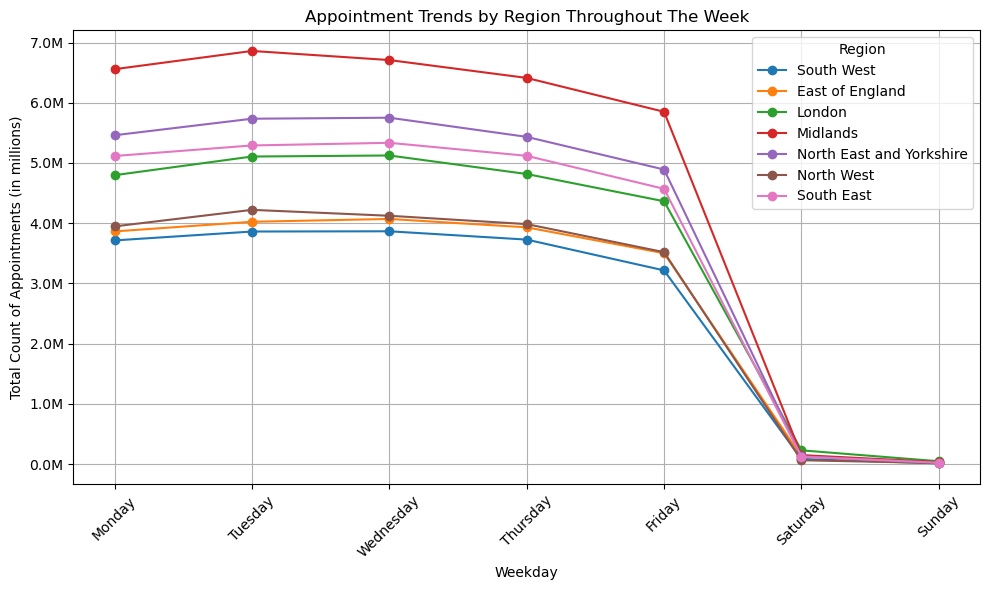

In [152]:

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


weekday_data = ad_region_weekday.groupby(['weekday', 'Region'])['count_of_appointments'].sum().reset_index()


weekday_data['weekday'] = pd.Categorical(weekday_data['weekday'], categories=weekday_order, ordered=True)
weekday_data = weekday_data.sort_values('weekday')


fig, ax = plt.subplots(figsize=(10, 6))


for region in weekday_data['Region'].unique():
    region_data = weekday_data[weekday_data['Region'] == region]
    ax.plot(region_data['weekday'], region_data['count_of_appointments'], marker='o', linestyle='-', label=region)


ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))


plt.xlabel('Weekday')
plt.ylabel('Total Count of Appointments (in millions)')
plt.title('Appointment Trends by Region Throughout The Week')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.grid(True)
plt.tight_layout()  
plt.savefig('Appointment Trends by Region Throughout The Week.png')
plt.show()

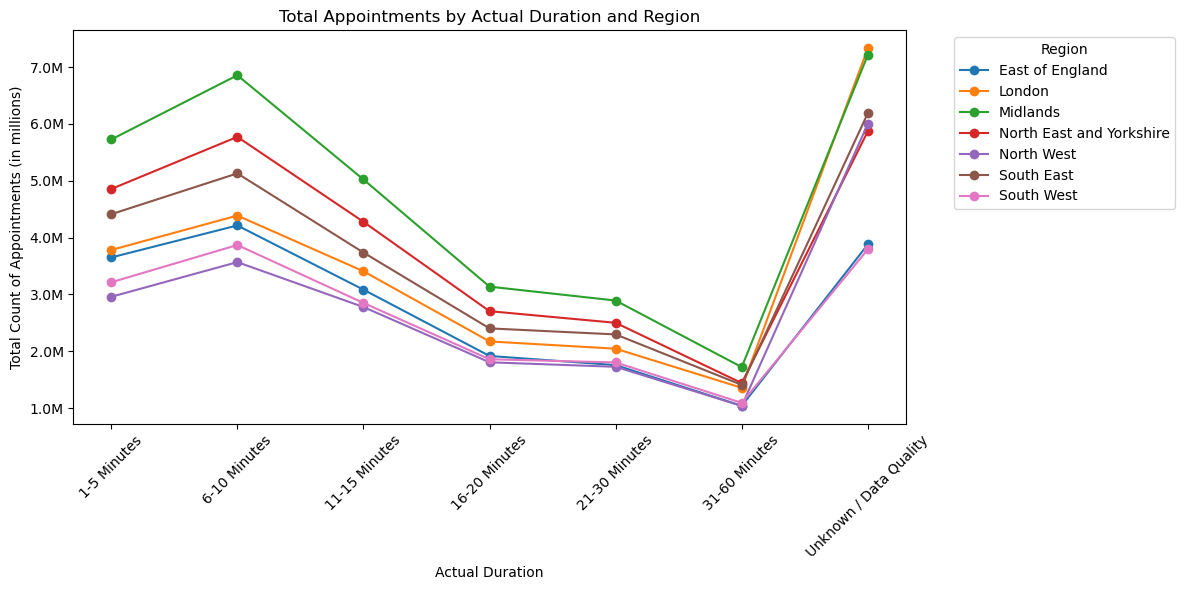

In [154]:

duration_order = [
    '1-5 Minutes', '6-10 Minutes', '11-15 Minutes', 
    '16-20 Minutes', '21-30 Minutes', '31-60 Minutes', 
    'Unknown / Data Quality'
]


duration_region_data = ad_region_weekday.groupby(['actual_duration', 'Region'])['count_of_appointments'].sum().unstack()


duration_region_data = duration_region_data.reindex(duration_order)


fig, ax = plt.subplots(figsize=(12, 6))


x_positions = np.arange(len(duration_order))  


for region in duration_region_data.columns:
    ax.plot(x_positions, duration_region_data[region], marker='o', linestyle='-', label=region)


ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))


plt.xlabel('Actual Duration')
plt.ylabel('Total Count of Appointments (in millions)')
plt.title('Total Appointments by Actual Duration and Region')


plt.xticks(x_positions, duration_order, rotation=45)


plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Total Appointments by Actual Duration and Region.png')
plt.show()

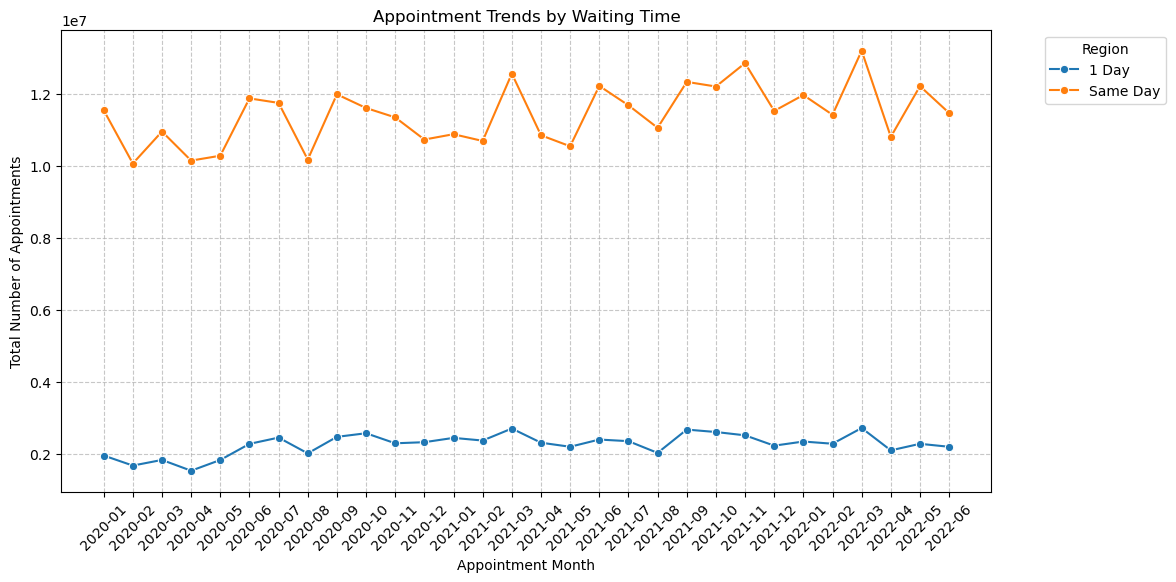

In [156]:


filtered_ar = ar[ar['time_between_book_and_appointment'].isin(['1 Day', 'Same Day'])]

# Grouping data: Sum of 'count_of_appointments' by 'appointment_month' and 'time_between_book_and_appointment'
appointment_trends = (
    filtered_ar.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=appointment_trends,
    x='appointment_month',
    y='count_of_appointments',
    hue='time_between_book_and_appointment',
    marker='o'
)


# Formatting the chart
plt.xlabel('Appointment Month')
plt.ylabel('Total Number of Appointments')
plt.title('Appointment Trends by Waiting Time')
plt.xticks(rotation=45)
plt.legend(title='Time Between Booking & Appointment')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


In [158]:

appointment_counts = (
    ar_region.groupby(['time_between_book_and_appointment', 'Region'])['count_of_appointments']
    .sum()
    .reset_index()
)


table = appointment_counts.pivot(index='time_between_book_and_appointment', columns='Region', values='count_of_appointments')


table_percentage = table.div(table.sum()) * 100


table_percentage = table_percentage.round(2)


time_order = [
    'Same Day', '1 Day', '2 to 7 Days', '8 to 14 Days', '15 to 21 Days', 
    '22 to 28 Days', 'More than 28 Days', 'Unknown / Data Quality'
]



table_percentage = table_percentage.reindex(time_order)






def highlight_max(s):
    is_max = s == s.max()
    return ['color: red; font-weight: bold' if v else '' for v in is_max]

styled_table = table_percentage.style.format("{:.2f}%").apply(highlight_max, axis=1)

styled_table

Region,East of England,London,Midlands,North East and Yorkshire,North West,South East,South West
time_between_book_and_appointment,,,,,,,
Same Day,46.52%,47.20%,47.89%,44.55%,46.96%,45.76%,43.32%
1 Day,8.48%,11.10%,8.41%,9.18%,9.59%,8.75%,8.31%
2 to 7 Days,19.91%,22.81%,19.96%,20.83%,20.27%,20.38%,20.80%
8 to 14 Days,11.66%,10.72%,11.41%,12.12%,11.39%,12.03%,12.71%
15 to 21 Days,6.07%,4.40%,5.63%,5.97%,5.74%,6.14%,6.56%
22 to 28 Days,3.74%,2.23%,3.38%,3.61%,3.41%,3.69%,4.23%
More than 28 Days,3.59%,1.40%,3.27%,3.71%,2.60%,3.22%,4.03%
Unknown / Data Quality,0.04%,0.14%,0.04%,0.04%,0.05%,0.04%,0.04%
